In [4]:
import pandas as pd 
import numpy as np 
import warnings
warnings.filterwarnings('ignore')

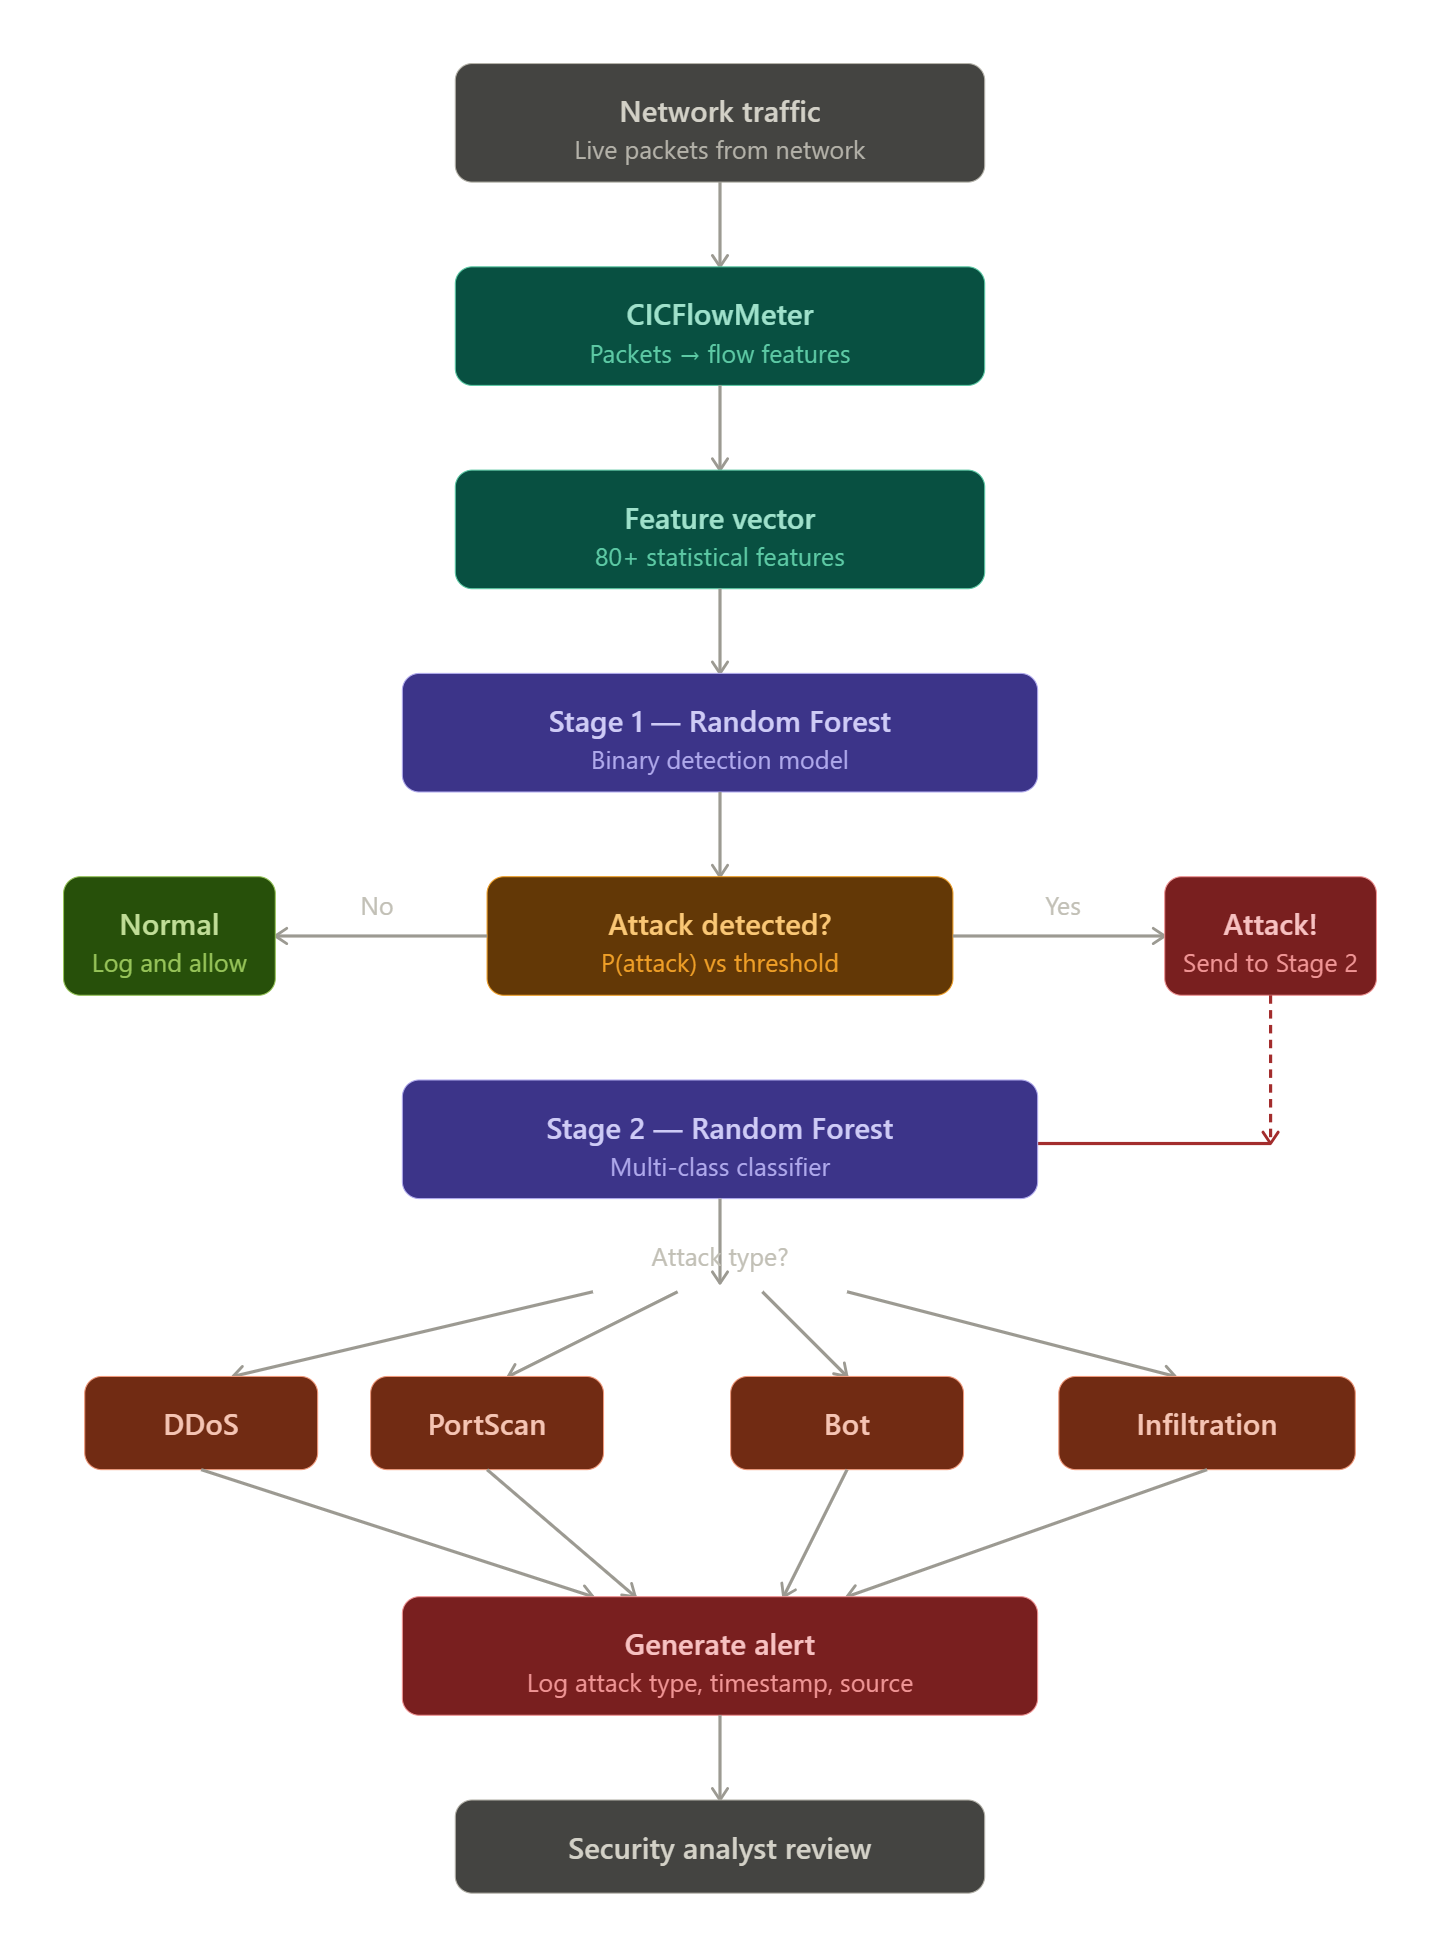](attachment:image.png)

# evaluation For Phase1 


In [5]:
df = pd.read_csv(r'C:\Users\Laptop Zone PTK\OneDrive\Desktop\Capstone-project\eda\cleaned_phase1_dataset.csv', on_bad_lines='skip')

In [6]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn import preprocessing
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [7]:
df.head()

,Destination Port,Flow Duration,Total Length of Fwd Packets,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Std,...,Down/Up Ratio,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,Active Std,Idle Mean,Idle Std,Label
0,54865,3.0,12,6.0,0.0,0.0,0.0,4.000000e+06,666666.66670,0.0,...,0,6.0,0.0,12,33,-1,0.0,0.0,0.0,0
1,55054,109.0,6,6.0,0.0,6.0,0.0,1.100917e+05,18348.62385,0.0,...,1,6.0,6.0,6,29,256,0.0,0.0,0.0,0
2,55055,52.0,6,6.0,0.0,6.0,0.0,2.307692e+05,38461.53846,0.0,...,1,6.0,6.0,6,29,256,0.0,0.0,0.0,0
3,46236,34.0,6,6.0,0.0,6.0,0.0,3.529412e+05,58823.52941,0.0,...,1,6.0,6.0,6,31,329,0.0,0.0,0.0,0
4,54863,3.0,12,6.0,0.0,0.0,0.0,4.000000e+06,666666.66670,0.0,...,0,6.0,0.0,12,32,-1,0.0,0.0,0.0,0


In [8]:
df.describe()

,Destination Port,Flow Duration,Total Length of Fwd Packets,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Std,...,Down/Up Ratio,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,Active Std,Idle Mean,Idle Std,Label
count,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,...,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06,1.428332e+06
mean,9.022252e+03,1.024297e+07,5.616576e+02,5.899883e+01,6.217587e+01,2.553846e+02,2.829037e+02,6.137393e+05,5.434598e+04,1.636655e+06,...,7.456369e-01,6.237530e+01,2.574797e+02,5.616368e+02,7.861642e+03,1.942556e+03,2.342376e+04,3.938736e+06,4.786005e+05,2.022051e-01
std,1.898654e+04,2.823465e+07,1.273040e+04,1.953117e+02,2.427213e+02,5.711192e+02,8.342705e+02,2.052967e+06,1.677420e+05,5.086296e+06,...,7.784611e-01,2.256903e+02,5.762427e+02,1.270937e+04,1.513729e+04,8.349285e+03,1.404256e+05,1.316760e+07,4.448732e+06,4.016445e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.338627e-02,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,8.600000e+01,6.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,2.058030e+02,9.389460e+00,0.000000e+00,...,0.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,-1.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.069200e+04,5.000000e+01,2.900000e+01,0.000000e+00,5.628571e+01,0.000000e+00,8.759543e+03,1.294959e+02,1.024809e+02,...,1.000000e+00,2.900000e+01,5.628571e+01,5.000000e+01,2.560000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.049000e+03,9.139490e+05,9.600000e+01,4.700000e+01,1.026320e+01,1.550000e+02,3.464102e+00,2.000000e+05,2.739726e+04,2.008214e+05,...,1.000000e+00,4.700000e+01,1.550000e+02,9.600000e+01,8.192000e+03,2.290000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.199952e+08,1.290000e+07,5.940857e+03,7.049469e+03,5.800500e+03,8.194660e+03,3.470000e+08,2.000000e+06,6.920000e+07,...,1.560000e+02,5.940857e+03,5.800500e+03,1.287034e+07,6.553500e+04,6.553500e+04,2.610000e+07,1.200000e+08,6.430000e+07,1.000000e+00


In [9]:
df.skew().sort_values(ascending=False)

Total Length of Fwd Packets    756.822493
Subflow Fwd Bytes              755.548601
Bwd Packets/s                   24.647806
Down/Up Ratio                   14.839983
Active Std                      12.013752
Idle Std                        10.853214
Flow Bytes/s                    10.713617
FIN Flag Count                   8.129973
Avg Fwd Segment Size             7.933309
Bwd IAT Mean                     7.786671
Fwd Packet Length Mean           7.340228
Fwd IAT Mean                     7.207760
Fwd Packet Length Std            6.907137
Bwd IAT Std                      5.832427
Init_Win_bytes_backward          5.275067
Fwd IAT Std                      4.619034
Flow IAT Std                     4.417281
Fwd PSH Flags                    4.402307
SYN Flag Count                   4.402307
Flow Packets/s                   4.285867
Idle Mean                        4.244786
Fwd Packets/s                    4.224314
Bwd Packet Length Std            4.172997
Packet Length Std                3

# training some models to see is there is any data leakage 

In [10]:
X_train, X_test, y_train, y_test=train_test_split(df.drop(columns="Label"),df["Label"],test_size=0.2,stratify=df["Label"],shuffle=True,random_state=32)

In [ ]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
Xtrain=std.fit_transform(X_train)
X_test=std.transform(X_test)


In [11]:
from sklearn.linear_model import SGDClassifier,LogisticRegression
# print(cross_val_score(SGDClassifier(),X_train,y_train,cv=4).mean())
# print(cross_val_score(LogisticRegression(),X_train,y_train,cv=4).mean())

In [12]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_jobs=-1).fit(X_train,y_train)

In [13]:
# print(cross_val_score(RandomForestClassifier(n_jobs=-1),X_train,y_train,cv=3).mean())

In [14]:
importance=pd.Series(rf.feature_importances_,index=X_train.columns).sort_values(ascending=False)

<Axes: >

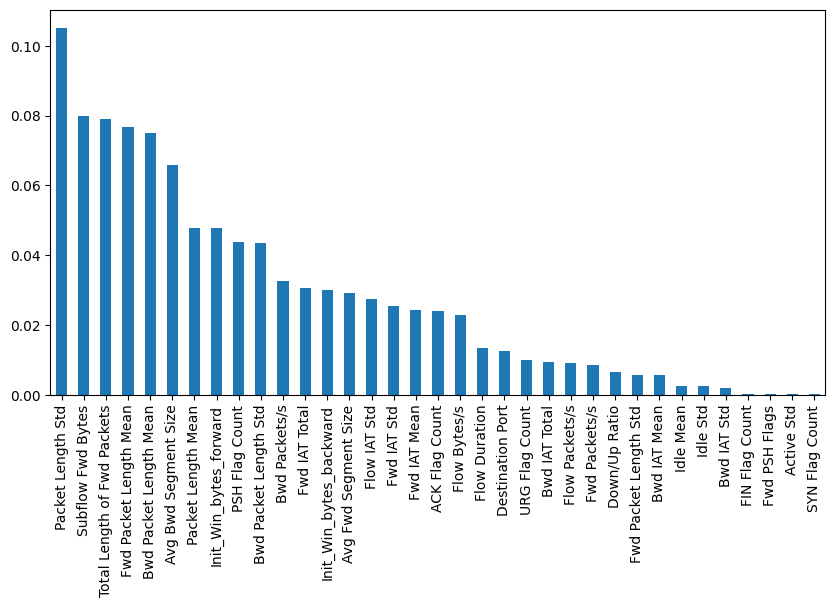

In [15]:
importance.plot(kind="bar", figsize=(10, 5))

In [16]:
print(classification_report(rf.predict(X_test),y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227884
           1       1.00      1.00      1.00     57783

    accuracy                           1.00    285667
   macro avg       1.00      1.00      1.00    285667
weighted avg       1.00      1.00      1.00    285667



In [17]:
print(confusion_matrix(rf.predict(X_test),y_test))

[[227677    207]
 [   227  57556]]


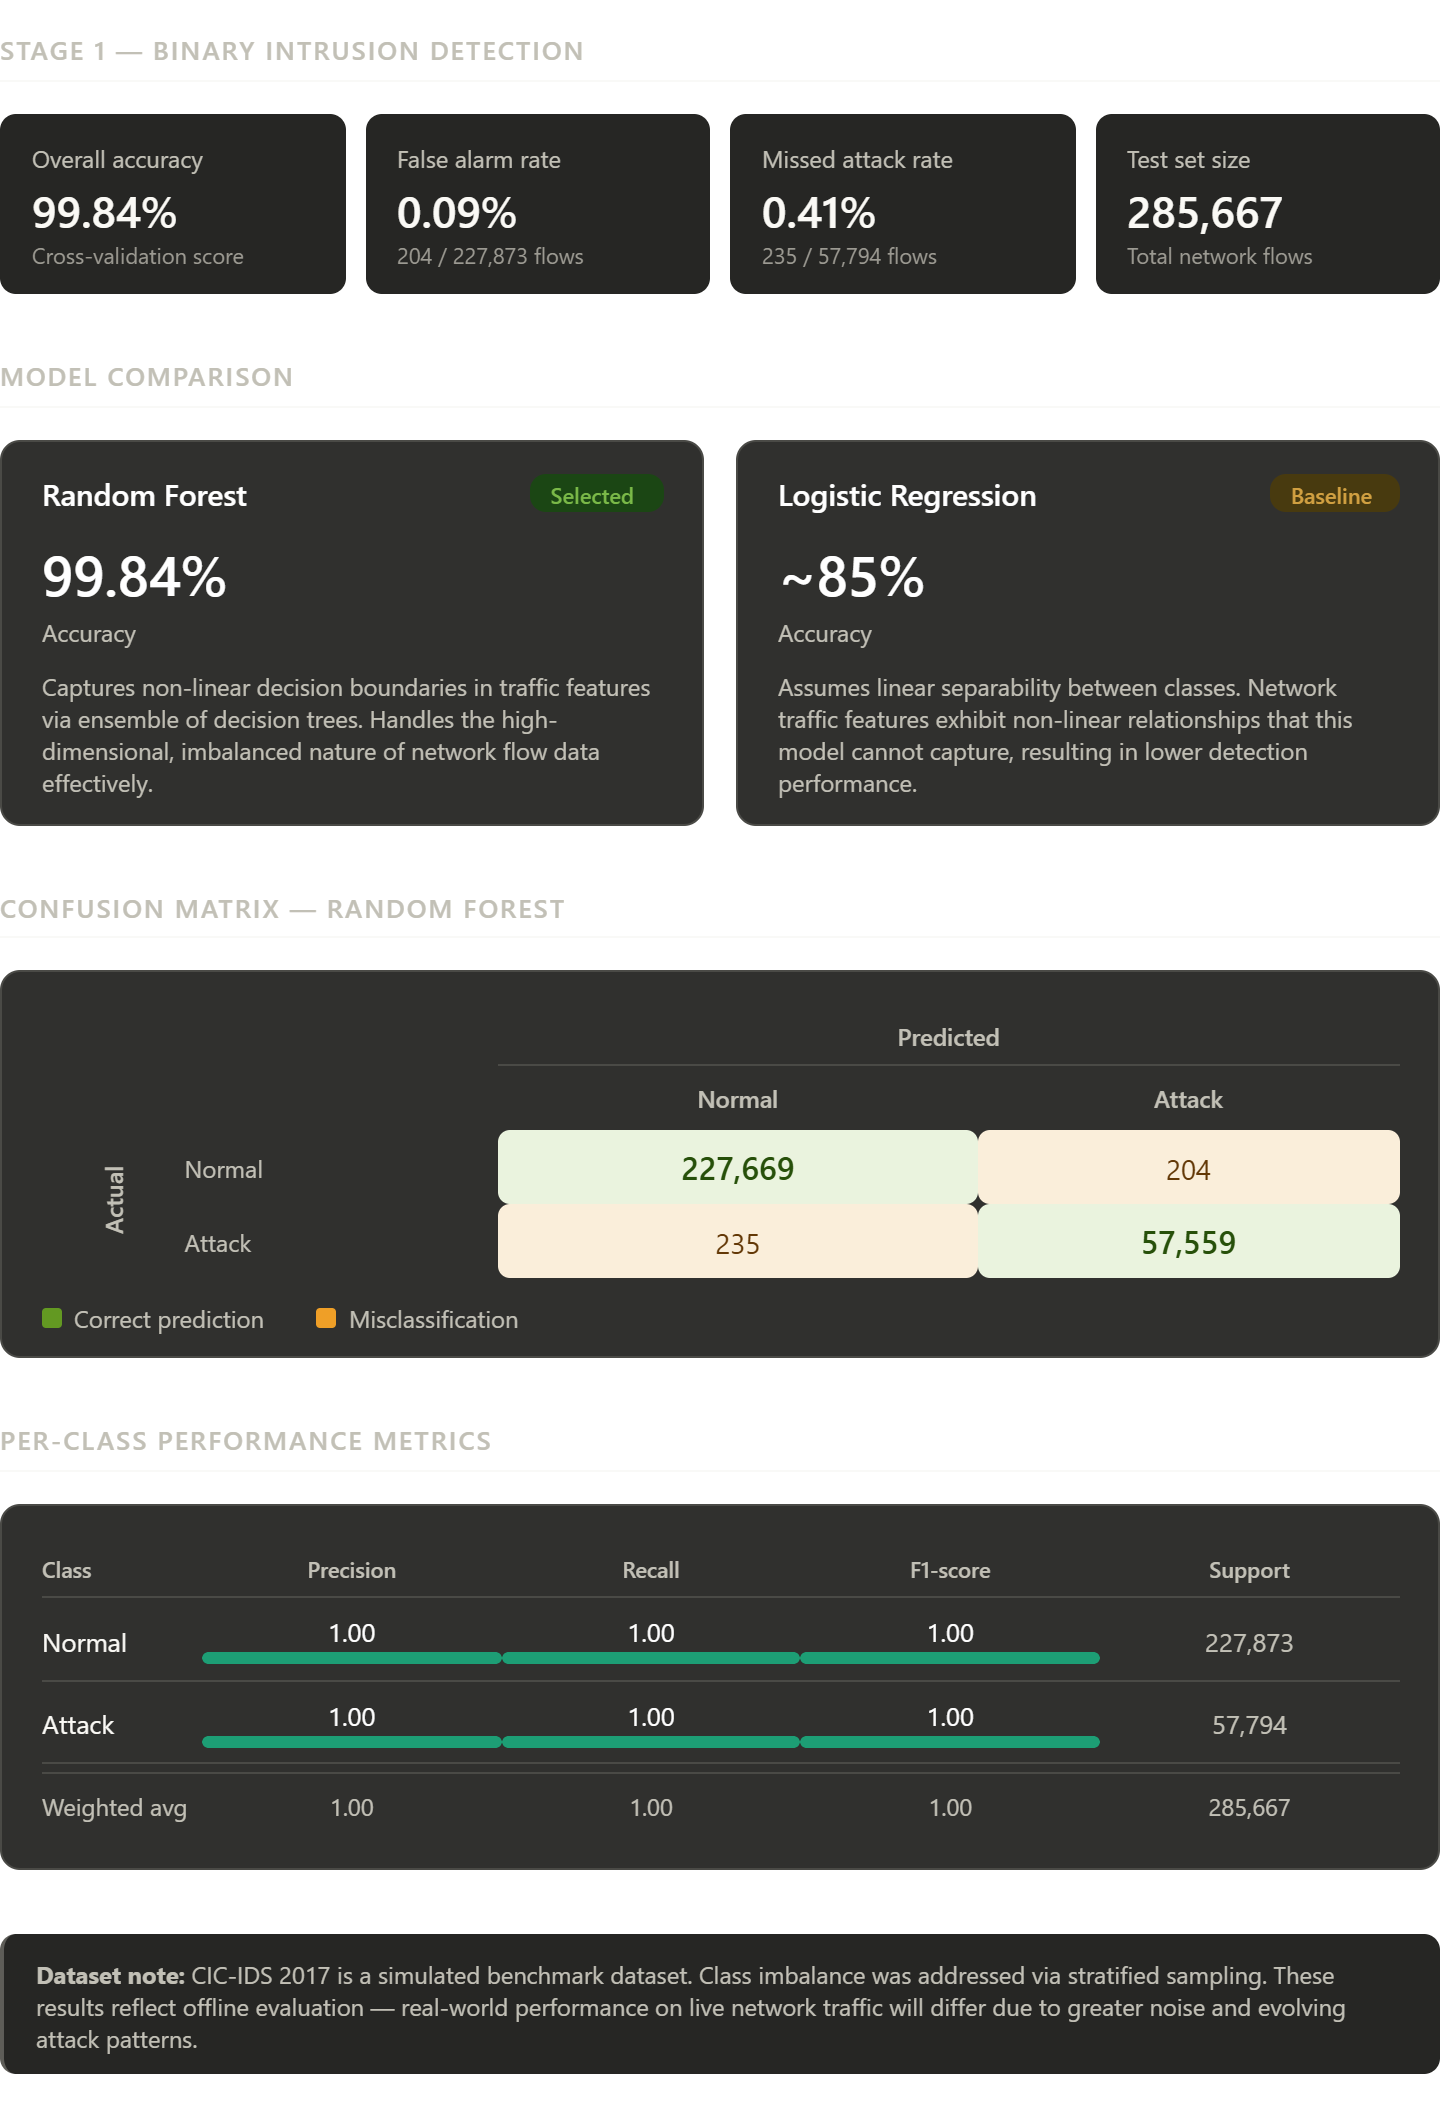

In [18]:
# we can use other models also phase2 cleaned 
df_x=pd.read_csv(r"C:\Users\Laptop Zone PTK\OneDrive\Desktop\Capstone-project\eda\phase2_cleaned.csv")

In [19]:
df_x.shape

(288816, 36)

In [20]:
df_x.isna().sum()

Destination Port               0
Flow Duration                  0
Total Length of Fwd Packets    0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
Bwd Packet Length Mean         0
Bwd Packet Length Std          0
Flow Bytes/s                   0
Flow Packets/s                 0
Flow IAT Std                   0
Fwd IAT Total                  0
Fwd IAT Mean                   0
Fwd IAT Std                    0
Bwd IAT Total                  0
Bwd IAT Mean                   0
Bwd IAT Std                    0
Fwd PSH Flags                  0
Fwd Packets/s                  0
Bwd Packets/s                  0
Packet Length Mean             0
Packet Length Std              0
FIN Flag Count                 0
SYN Flag Count                 0
PSH Flag Count                 0
ACK Flag Count                 0
URG Flag Count                 0
Down/Up Ratio                  0
Avg Fwd Segment Size           0
Avg Bwd Segment Size           0
Subflow Fwd Bytes              0
Init_Win_b

In [21]:
df_x.duplicated().sum()

np.int64(68131)

In [22]:
df_x.columns

Index(['Destination Port', 'Flow Duration', 'Total Length of Fwd Packets',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Fwd PSH Flags', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Mean',
       'Packet Length Std', 'FIN Flag Count', 'SYN Flag Count',
       'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio',
       'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'Active Std',
       'Idle Mean', 'Idle Std', 'Label'],
      dtype='object')

In [23]:
df_x.drop_duplicates(inplace=True)

In [44]:
df_x["Label"].value_counts()

Label
DDoS            128012
PortScan         90694
Bot               1948
Infiltration        31
Name: count, dtype: int64

In [25]:
xtrain,xtest,ytrain,ytest=train_test_split(df_x.drop(columns="Label"),df_x["Label"],test_size=0.2,stratify=df_x["Label"],shuffle=True)

In [26]:
# cross_val_score(RandomForestClassifier(n_jobs=-1),xtrain,ytrain,cv=5).mean()

In [27]:
final_model=RandomForestClassifier(n_jobs=-1).fit(xtrain,ytrain)

In [28]:
prediction=final_model.predict(xtest)


In [88]:
print(classification_report(ytest,prediction))
print("--------------------------------")
print(confusion_matrix(ytest,prediction))

              precision    recall  f1-score   support

         Bot       1.00      1.00      1.00       390
        DDoS       1.00      1.00      1.00     25602
Infiltration       1.00      1.00      1.00         6
    PortScan       1.00      1.00      1.00     18139

    accuracy                           1.00     44137
   macro avg       1.00      1.00      1.00     44137
weighted avg       1.00      1.00      1.00     44137

--------------------------------
[[  390     0     0     0]
 [    0 25602     0     0]
 [    0     0     6     0]
 [    0     0     0 18139]]


In [30]:
df_x.Label.value_counts(normalize=True)

Label
DDoS            0.580067
PortScan        0.410966
Bot             0.008827
Infiltration    0.000140
Name: proportion, dtype: float64

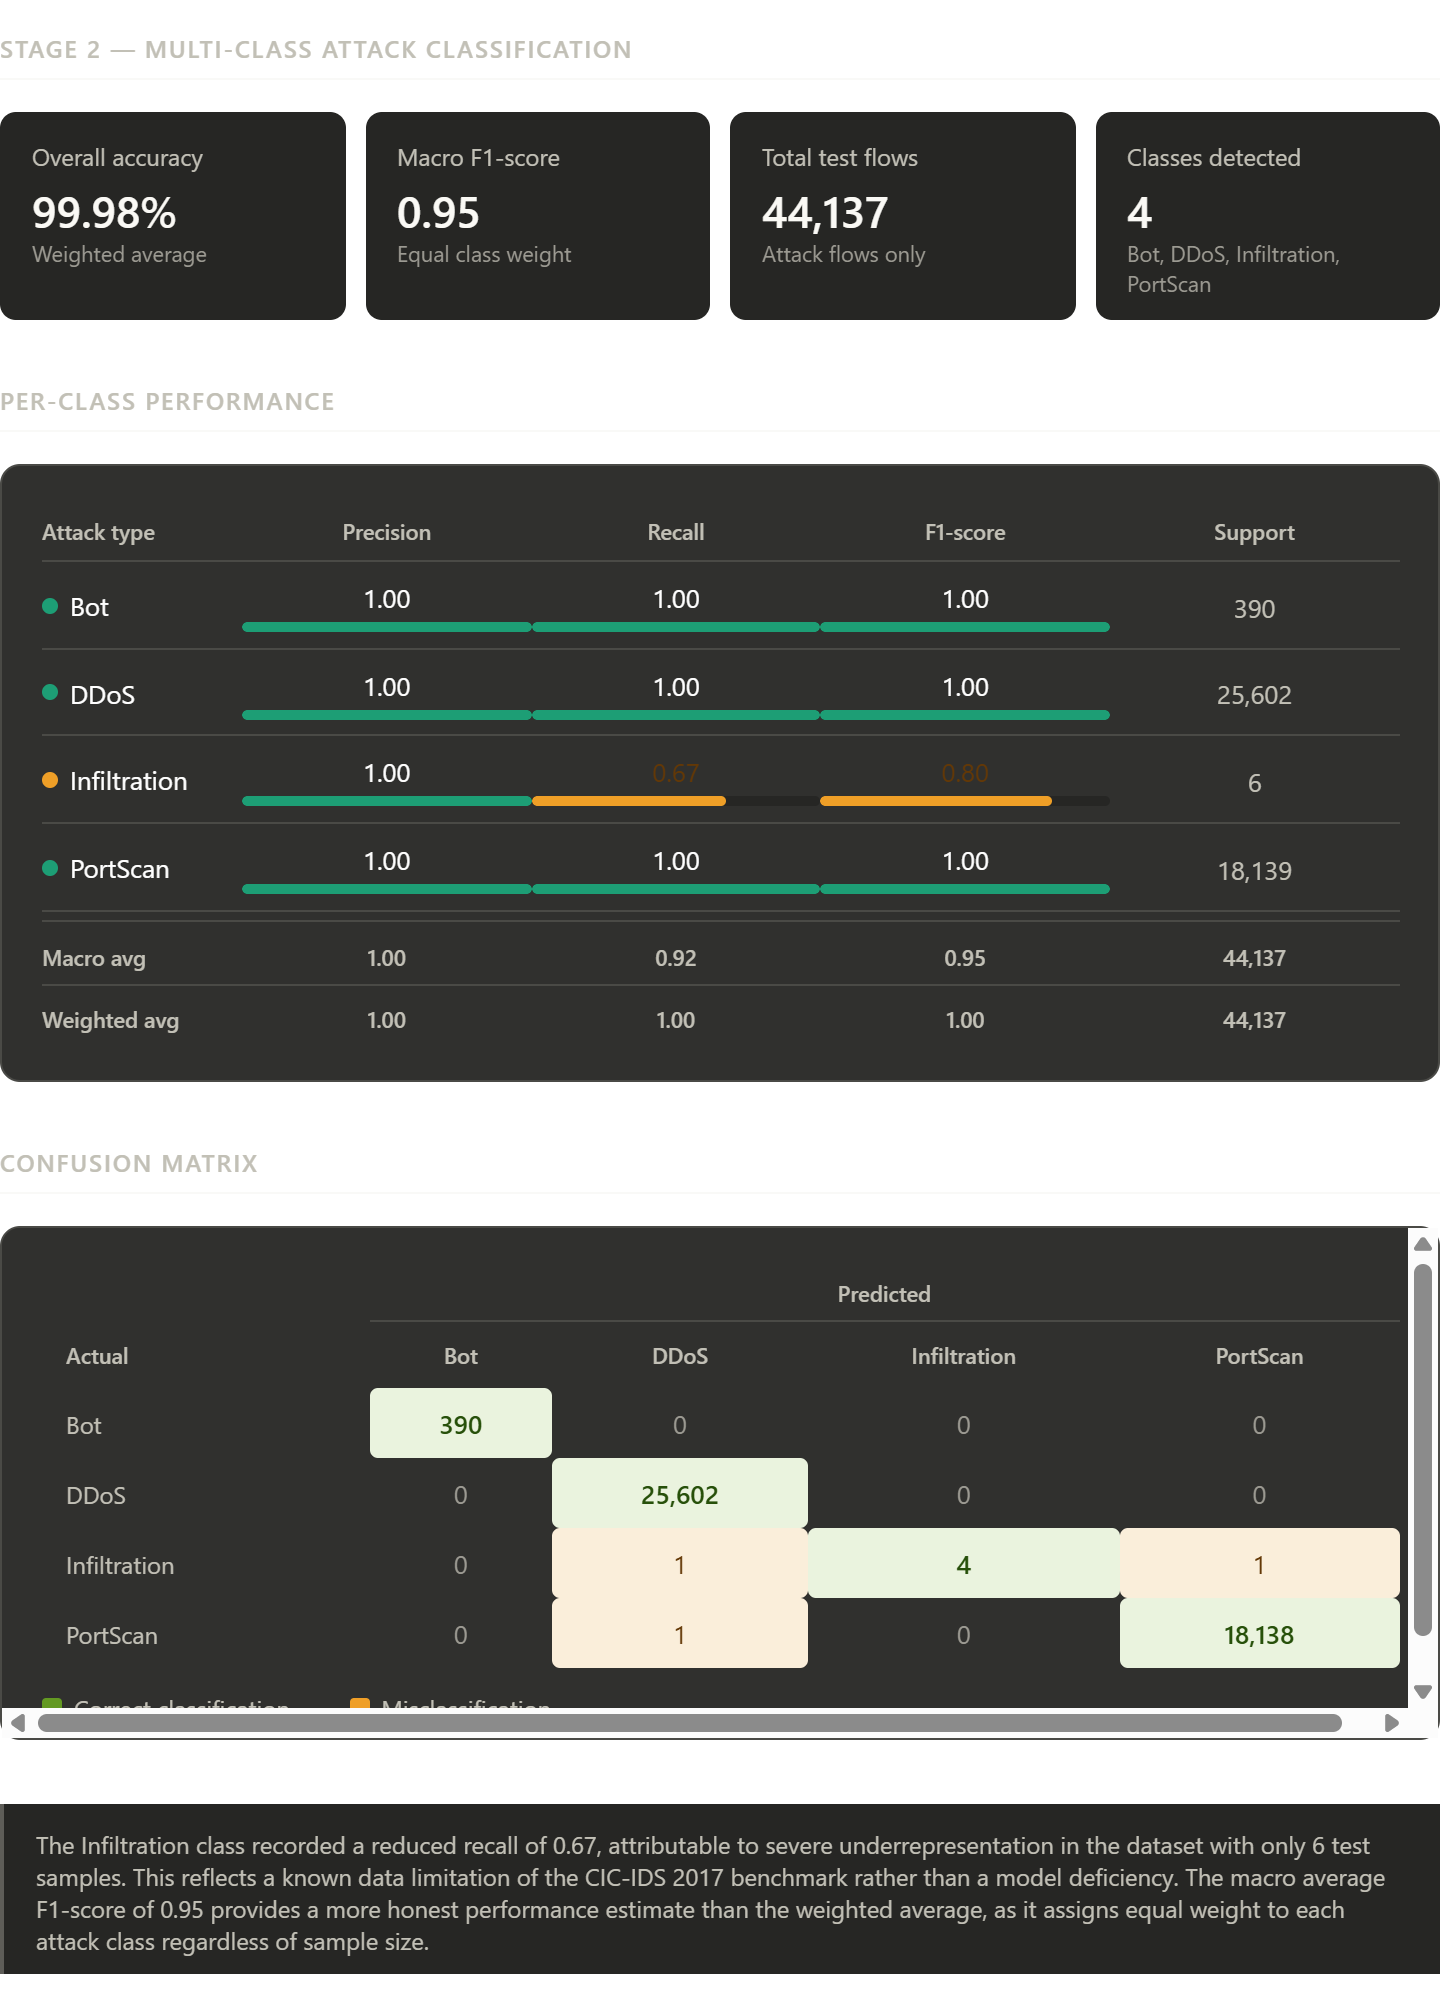

# Threshold Tuning of Phase1 Dataset and Phase1 and Phase2 dataset

In [ ]:
yprobs=rf.predict_proba(X_test)[:,1]# Binary only 

In [62]:
def threshold_tuning(ypred,ytest,threshold):
    ypredx=(ypred >= threshold).astype(int)
    print(classification_report(ypredx,ytest))
    print("---------------------------------")
    print(recall_score(ypredx,ytest))
    print("\n")
    print(confusion_matrix(ypredx,ytest))


In [81]:
threshold_tuning(yprobs,y_test,0.12)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    227501
           1       1.00      0.99      1.00     58166

    accuracy                           1.00    285667
   macro avg       1.00      1.00      1.00    285667
weighted avg       1.00      1.00      1.00    285667

---------------------------------
0.9927792868686174


[[227484     17]
 [   420  57746]]


In [86]:
X_train.columns

Index(['Destination Port', 'Flow Duration', 'Total Length of Fwd Packets',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Fwd PSH Flags', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Mean',
       'Packet Length Std', 'FIN Flag Count', 'SYN Flag Count',
       'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio',
       'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'Active Std',
       'Idle Mean', 'Idle Std'],
      dtype='object')

In [87]:
import pickle


# Save the model
with open('model_phase1.pkl', 'wb') as f:
    pickle.dump(rf, f)


In [90]:
final_model.predict(X_test)

array(['DDoS', 'PortScan', 'DDoS', ..., 'PortScan', 'DDoS', 'DDoS'],
      shape=(285667,), dtype=object)

In [91]:
df["Label"].value_counts()

Label
0    1139516
1     288816
Name: count, dtype: int64

In [103]:
X_train.columns

Index(['Destination Port', 'Flow Duration', 'Total Length of Fwd Packets',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Fwd PSH Flags', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Mean',
       'Packet Length Std', 'FIN Flag Count', 'SYN Flag Count',
       'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Down/Up Ratio',
       'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Bytes',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'Active Std',
       'Idle Mean', 'Idle Std'],
      dtype='object')